# ¡Hola Carlos! <a class="tocSkip"></a>

Mi nombre es Oscar Flores y tengo el gusto de revisar tu proyecto. Si tienes algún comentario que quieras agregar en tus respuestas te puedes referir a mi como Oscar, no hay problema que me trates de tú.

Si veo un error en la primera revisión solamente lo señalaré y dejaré que tú encuentres de qué se trata y cómo arreglarlo. Debo prepararte para que te desempeñes como especialista en Data, en un trabajo real, el responsable a cargo tuyo hará lo mismo. Si aún tienes dificultades para resolver esta tarea, te daré indicaciones más precisas en una siguiente iteración.

Te dejaré mis comentarios más abajo - **por favor, no los muevas, modifiques o borres**

Comenzaré mis comentarios con un resumen de los puntos que están bien, aquellos que debes corregir y aquellos que puedes mejorar. Luego deberás revisar todo el notebook para leer mis comentarios, los cuales estarán en rectángulos de color verde, amarillo o rojo como siguen:

<div class='alert alert-block alert-success'>
<b>Comentario de Reviewer</b> <a class='tocSkip'></a>

Muy bien! Toda la respuesta fue lograda satisfactoriamente.
</div>

<div class='alert alert-block alert-warning'>
<b>Comentario de Reviewer</b> <a class='tocSkip'></a>

Existen detalles a mejorar. Existen recomendaciones.
</div>

<div class='alert alert-block alert-danger'>

<b>Comentario de Reviewer</b> <a class='tocSkip'></a>

Se necesitan correcciones en el bloque. El trabajo no puede ser aceptado con comentarios en rojo sin solucionar.
</div>

Cualquier comentario que quieras agregar entre iteraciones de revisión lo puedes hacer de la siguiente manera:

<div class='alert alert-block alert-info'>
<b>Respuesta estudiante.</b> <a class='tocSkip'></a>
</div>

Mucho éxito en el proyecto!

## Resumen de la revisión v1 <a class="tocSkip"></a>

<div class="alert alert-block alert-danger">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Hola Carlos, ¿cómo estás? Espero que todo esté bien por tu lado.
    
Felicitaciones por completar todos los items del notebook, veo bastante trabajo a lo largo de este. En general, está todo correcto y con una buena aplicación del código necesario para lograr los objetivos. Tan solo resta que corrijas el segundo test de hipótesis, la celda del código no compila correctamente.

Si tienes dudas o preguntas, me las puedes dejar en comentario azul, con gusto las responderé en la siguiente iteración.

Saludos!


</div>

<div class="alert alert-block alert-success">
<b>Comentario de Revisor  v </b> <a class="tocSkip"></a>

¡Felicitaciones! Hiciste un gran trabajo con las últimas correcciones. El notebook está completo y todo está en orden, por lo que tu proyecto queda aprobado. Lo que aprendiste y aplicaste aquí te servirá muchísimo en futuros desafíos de análisis de datos. ¡Mucho éxito!

Saludos.

</div>

----

# Proyecto - Módulo 1: Análisis de dataset "ice" Tienda de videojuegos

## Objetivos Generales del Proyecto



# Paso 1: Apertura y Exploración Inicial de Datos

En este primer paso, cargaremos el dataset de videojuegos y realizaremos una exploración inicial para comprender la estructura y características generales de nuestros datos. 

**Objetivos de esta sección:**
- Cargar el dataset desde la ruta especificada
- Examinar las dimensiones y estructura general de los datos
- Identificar los tipos de datos de cada columna
- Realizar una primera inspección visual de la información disponible
- Detectar posibles problemas o inconsistencias en los datos

Esta exploración inicial nos permitirá tener una visión general del dataset antes de proceder con la limpieza y preparación de los datos.

In [1]:
# importamos librerías necesariaas
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as st
import seaborn as sns

In [2]:
# Empezamos creando un DataFrame para el análisis exploratorio
df = pd.read_csv("/datasets/games.csv")

In [3]:
# Imprimimos una muestra de los datos
df.head()

,Name,Platform,Year_of_Release,Genre,NA_sales,EU_sales,JP_sales,Other_sales,Critic_Score,User_Score,Rating
0,Wii Sports,Wii,2006.0,Sports,41.36,28.96,3.77,8.45,76.0,8,E
1,Super Mario Bros.,NES,1985.0,Platform,29.08,3.58,6.81,0.77,NaN,NaN,NaN
2,Mario Kart Wii,Wii,2008.0,Racing,15.68,12.76,3.79,3.29,82.0,8.3,E
3,Wii Sports Resort,Wii,2009.0,Sports,15.61,10.93,3.28,2.95,80.0,8,E
4,Pokemon Red/Pokemon Blue,GB,1996.0,Role-Playing,11.27,8.89,10.22,1.00,NaN,NaN,NaN


Con esta muestra identificamos que el archivo se dividió correctamente en columnas dentro del df, además hacemos un sondeo preliminar de los datos.

In [4]:
# Revisamos a detalle el Dataframe para detectar valores ausentes, tipos de datos y nombres de las columnas, así como extención del df
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16715 entries, 0 to 16714
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             16713 non-null  object 
 1   Platform         16715 non-null  object 
 2   Year_of_Release  16446 non-null  float64
 3   Genre            16713 non-null  object 
 4   NA_sales         16715 non-null  float64
 5   EU_sales         16715 non-null  float64
 6   JP_sales         16715 non-null  float64
 7   Other_sales      16715 non-null  float64
 8   Critic_Score     8137 non-null   float64
 9   User_Score       10014 non-null  object 
 10  Rating           9949 non-null   object 
dtypes: float64(6), object(5)
memory usage: 1.4+ MB


<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Excelente uso de las funciones de `head()` e `info()`. Esto permite observar claramente el tamaño de la data, donde hay nulos y ver una muestra. 

</div>

Se identifica que la columna "User_Score" es de tipo str, así que lo cambiamos a flotante, no obstante, se identifica que esta columna tiene valores string que deben ser reemplazados por un valor NaN en la etapa de pre-procesamiento de datos

In [5]:
# Revisamos si existen valores ausentes
df.isna().sum()

Name                  2
Platform              0
Year_of_Release     269
Genre                 2
NA_sales              0
EU_sales              0
JP_sales              0
Other_sales           0
Critic_Score       8578
User_Score         6701
Rating             6766
dtype: int64

Los valores duplicados existentes obedecen a la falta de calificación por la crítica principalmente, por ende es un cpomportamiento esperable

In [6]:
# Revisamos si existen valores duplicados
df.duplicated().sum()

0

No identificamos valores duplicados

In [7]:
df["User_Score"].value_counts()

tbd    2424
7.8     324
8       290
8.2     282
8.3     254
       ... 
0.5       2
0.7       2
1.3       2
9.7       1
0         1
Name: User_Score, Length: 96, dtype: int64

## Análisis general del paso 1: pertura y exploración de datos:

**Estructura y Dimensiones del Dataset:**

- Dataset contiene 16,715 registros con 11 columnas
- Los datos cubren videojuegos desde 1980 hasta 2016
- Uso de memoria eficiente: 1.4 MB

**Tipos de Datos Identificados:**

6 columnas numéricas (float64): ventas y scores
5 columnas categóricas (str): nombres, plataformas, géneros
Problema detectado: User_Score es string por valores "tbd"
Calidad de los Datos:

**Valores ausentes críticos:**

- Name: 2 registros (mínimo impacto)
- Genre: 2 registros (mínimo impacto)
- Year_of_Release: 269 registros (impacto moderado)

**Valores ausentes significativos:**

- Critic_Score: 8,578 registros (51.3% del dataset)
- User_Score: 6,701 registros (40.1% del dataset)
- Rating: 6,766 registros (40.5% del dataset)
- Sin valores duplicados (buena calidad de datos)

**Problemas Detectados:**

- User_Score contiene 2,424 valores "tbd" (to be determined)
- Altos porcentajes de valores ausentes en scores y ratings
- Necesidad de conversión de tipos de datos

**Inspección Visual Inicial:**

- Los juegos más exitosos son títulos de Nintendo (Wii Sports, Mario series)
- Las ventas varían drásticamente (desde 0.01 hasta 82.54 millones)
- Presencia de múltiples plataformas y géneros diversos

**Preparación para Siguientes Pasos:**

- Se requiere limpieza de valores ausentes críticos
- Conversión obligatoria de User_Score a numérico
- Estrategia clara para manejar datos faltantes sin sesgar análisis

# Paso 2: Preparación y Limpieza de Datos

En esta sección nos enfocaremos en preparar nuestro dataset para el análisis preliminar. La calidad de nuestros datos es fundamental para obtener insights confiables y precisos.

**Objetivos de esta sección:**
- Estandarizar los nombres de las columnas (convertir a minúsculas)
- Convertir los datos a los tipos apropiados para el análisis
- Identificar y tratar los valores ausentes de manera estratégica
- Manejar casos especiales como "TBD" (To Be Determined)
- Crear nuevas variables derivadas (ventas totales por juego)
- Documentar todas las decisiones de limpieza y sus justificaciones

Tener un dataset bien preparado es fundamentala para hacer un análisis exitoso

In [8]:
# Convertimos a numérico la columna "User_Score" y usamos errors="coerce" para manejar valores no numéricos
df["User_Score"] = pd.to_numeric(df["User_Score"], errors="coerce")

In [9]:
# Ajustamos los nombres de las columnas para garantizar la estructura lower_case
df.columns = df.columns.str.lower()

# Verificamos los cambios hechos
print("Nombres de columnas actualizados:")
print(df.columns)

Nombres de columnas actualizados:
Index(['name', 'platform', 'year_of_release', 'genre', 'na_sales', 'eu_sales',
       'jp_sales', 'other_sales', 'critic_score', 'user_score', 'rating'],
      dtype='object')


<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Muy bien con el uso de snakecase, es un buen estándar para las columnas, lo cual le da más orden al análisis.

</div>

In [10]:
# Aplicamos la estrategia de tratamiento de valores ausentes

# Eliminamos filas con valores ausentes críticos
df_clean = df.dropna(subset=['name', 'genre', 'year_of_release']).copy()
df_clean['year_of_release'] = df_clean['year_of_release'].astype(int)

# Convertimos year_of_release a entero
df_clean.loc[:, 'year_of_release'] = df_clean['year_of_release'].astype(int)

# Verificamos los cambios realizados
print("Datos antes de limpieza:", len(df))
print("Datos después de limpieza:", len(df_clean))
print("Filas eliminadas:", len(df) - len(df_clean))

print("\nValores ausentes después de limpieza:")
print(df_clean.isna().sum())

Datos antes de limpieza: 16715
Datos después de limpieza: 16444
Filas eliminadas: 271

Valores ausentes después de limpieza:
name                  0
platform              0
year_of_release       0
genre                 0
na_sales              0
eu_sales              0
jp_sales              0
other_sales           0
critic_score       8461
user_score         8981
rating             6676
dtype: int64


<div class="alert alert-block alert-success">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>

Buen trabajo en el tratamiento de los valores faltantes. En aquellas columnas con una alta proporción de datos ausentes, es buena idea optar por mantener los nulos o reemplazarlos por un valor que permita identificarlos claramente. En particular, para critic_score y user_score, la cantidad de información disponible no es suficiente para realizar una imputación confiable. Completar estos campos con la media o la mediana podría distorsionar significativamente los resultados, introduciendo un sesgo importante en el análisis, por lo que la decisión tomada resulta adecuada y bien justificada.



</div>

In [11]:
# Calculamos ventas totales para cada juego
df_clean['total_sales'] = df_clean['na_sales'] + df_clean['eu_sales'] + df_clean['jp_sales'] + df_clean['other_sales']

# Verificamos la nueva columna
print("Estadísticas de ventas totales:")
print(df_clean['total_sales'].describe())

# imprimimos el top 5 de juegos de acuerdo a las ventas totales
print("\nPrimeros 5 juegos con mayores ventas totales:\n")
top_games = df_clean.nlargest(5, 'total_sales')[['name', 'platform', 'year_of_release', 'total_sales']]
print(top_games)

Estadísticas de ventas totales:
count    16444.000000
mean         0.536023
std          1.558786
min          0.000000
25%          0.060000
50%          0.170000
75%          0.470000
max         82.540000
Name: total_sales, dtype: float64

Primeros 5 juegos con mayores ventas totales:

                       name platform  year_of_release  total_sales
0                Wii Sports      Wii             2006        82.54
1         Super Mario Bros.      NES             1985        40.24
2            Mario Kart Wii      Wii             2008        35.52
3         Wii Sports Resort      Wii             2009        32.77
4  Pokemon Red/Pokemon Blue       GB             1996        31.38


<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Muy bien, también podrías haber usado

```python
    df[['na_sales','jp_sales','eu_sales','other_sales']].sum(axis=1)
```
</div>

# Conclusiones del Paso 2 - Preparación y Limpieza de Datos

**Conversiones de Datos Necesarias**
- **User_Score**: Convertida de string a float64 usando `pd.to_numeric()` con `errors="coerce"`
- **Razón**: La columna contenía valores "tbd" (to be determined) que impedían análisis numérico
- **Justificación**: Los valores "tbd" se convirtieron automáticamente en NaN, permitiendo cálculos estadísticos

**Estandarización de Estructura**
- **Nombres de columnas**: Convertidos a minúsculas para consistencia
- **Year_of_Release**: Convertida a entero después de eliminar valores ausentes
- **Justificación**: Facilita manipulación y evita errores por mayúsculas/minúsculas

**Estrategia de Manejo de Valores Ausentes**
- **Eliminados**: Name, Genre, Year_of_Release (271 filas totales)
- **Mantenidos**: Critic_Score, User_Score, Rating (preservados como NaN)
- **Justificación**: Evitar sesgos por imputación en scores críticos y mantener datos para análisis de ventas

**Cálculo de Ventas Totales - Hallazgos Preliminares**
- **Fórmula**: total_sales = NA_sales + EU_sales + JP_sales + Other_sales
- **Estadísticas clave**:
  - Media: 0.54 millones por juego
  - Mediana: 0.17 millones (indica distribución sesgada)
  - Máximo: 82.54 millones (Wii Sports)
- **Top 5 juegos**: Wii Sports, Super Mario Bros., Mario Kart Wii, Wii Sports Resort, Pokemon Red/Blue

**Calidad de Datos Post-Limpieza**
- **Dataset final**: 16,444 juegos (98.4% del original)
- **Integridad**: Columnas críticas sin valores ausentes
- **Preparado**: Listo para análisis estadístico y visualizaciones

**Insights Preliminares del Mercado**
- **Concentración**: Unos pocos juegos dominan las ventas (cola larga)
- **Éxito masivo**: Wii Sports supera por más del doble al segundo lugar
- **Diversidad**: Las ventas varían enormemente entre títulos exitosos y promedio


# Paso 3: Análisis de Datos

**Objetivos de esta sección:**

- **Análisis temporal:** Evaluar la cantidad de juegos lanzados por año y determinar períodos con datos significativos
- **Evolución de plataformas:** Identificar plataformas líderes, analizar ciclos de vida y tendencias de crecimiento/declive
- **Selección de período relevante:** Determinar el rango de años óptimo para construir el modelo predictivo de 2017
- **Identificación de plataformas rentables:** Seleccionar las plataformas con mayor potencial comercial
- **Análisis de distribución de ventas:** Crear boxplots por plataforma y evaluar diferencias significativas
- **Correlación reseñas-ventas:** Analizar la relación entre puntuaciones de usuarios/críticos y ventas globales
- **Comparación multiplataforma:** Evaluar el rendimiento de los mismos juegos en diferentes plataformas  
- **Análisis por género:** Identificar géneros más rentables y patrones de ventas por categoría

**Entregables esperados:**
- Gráficos de tendencias temporales
- Visualizaciones de ventas por plataforma
- Diagramas de caja comparativos
- Gráficos de dispersión y análisis de correlación
- Conclusiones sobre géneros más exitosos

*** JUEGOS LANZADOS POR AÑO ***
year_of_release
1980       9
1981      46
1982      36
1983      17
1984      14
1985      14
1986      21
1987      16
1988      15
1989      17
1990      16
1991      41
1992      43
1993      60
1994     121
1995     219
1996     263
1997     289
1998     379
1999     338
2000     350
2001     482
2002     829
2003     775
2004     762
2005     939
2006    1006
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
2012     653
2013     544
2014     581
2015     606
2016     502
dtype: int64

*** ANÁLISIS DE SIGNIFICANCIA DE PERÍODOS ***
Períodos con menos de 100 juegos (posiblemente no significativos):
year_of_release
1980     9
1981    46
1982    36
1983    17
1984    14
1985    14
1986    21
1987    16
1988    15
1989    17
1990    16
1991    41
1992    43
1993    60
dtype: int64

Períodos con mayor actividad (más de 1000 juegos):
year_of_release
2006    1006
2007    1197
2008    1427
2009    1426
2010    1255
2011    1136
dtype: int64


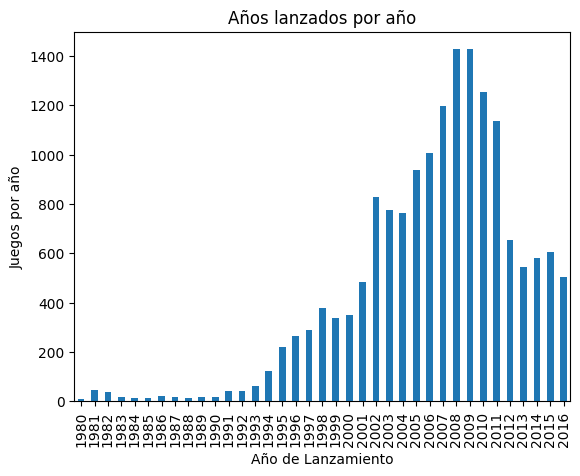

In [33]:
# Juegos lanzados por año y significancia de períodos
games_per_year = df_clean.groupby('year_of_release').size()

print("*** JUEGOS LANZADOS POR AÑO ***")
print(games_per_year)

print("\n*** ANÁLISIS DE SIGNIFICANCIA DE PERÍODOS ***")
print("Períodos con menos de 100 juegos (posiblemente no significativos):")
low_activity_years = games_per_year[games_per_year < 100]
print(low_activity_years)

print("\nPeríodos con mayor actividad (más de 1000 juegos):")
high_activity_years = games_per_year[games_per_year > 1000]
print(high_activity_years)


# agregamos gráfica de barras para mostrar evolución por año
games_per_year.plot(kind="bar",
                   xlabel="Año de Lanzamiento",
                   ylabel="Juegos por año",
                    title="Años lanzados por año",
                    )

plt.show()

<div class="alert alert-block alert-success">
<b>Comentario de Revisor              </b><a class="tocSkip"></a>


Muy bien, aunque idealmente hubieses mostrado un gráfico con los datos calculados en esta tabla.


</div>


=== TOP 5 PLATAFORMAS PRINCIPALES ===
platform
PS2     1233.56
X360     961.24
PS3      931.34
Wii      891.18
DS       802.78
Name: total_sales, dtype: float64


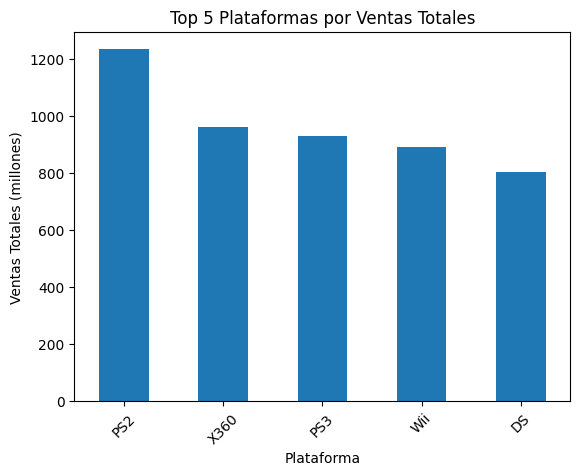

In [13]:
# Plataformas con mayores ventas totales
platform_sales = df_clean.groupby('platform')['total_sales'].sum().sort_values(ascending=False)

print("\n=== TOP 5 PLATAFORMAS PRINCIPALES ===")
top_platforms = platform_sales.head(5)
print(top_platforms)

# Creamos gráfico para mostrar top 5 plataformas
top_platforms.plot(kind='bar')
plt.title('Top 5 Plataformas por Ventas Totales')
plt.xlabel('Plataforma')
plt.ylabel('Ventas Totales (millones)')
plt.xticks(rotation=45)
plt.show()


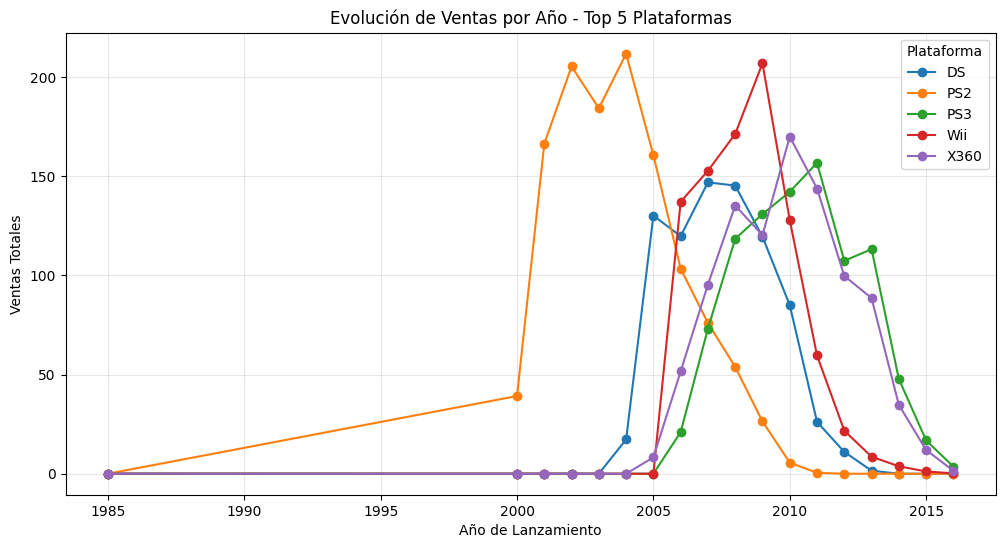

In [14]:
# Ahora vamos a mostrar la evolución por año por plataforma
# primero agrupamos por plataforma y año de lanzamiento, sumando las ventas totales
platform_year_sales = df_clean.groupby(['platform', 'year_of_release'])['total_sales'].sum().reset_index()

# Filtramos el top 5 de plataformas y almacenamos en una nueva variable
top_5_platforms = top_platforms.index.tolist()
top_platforms_evolution = platform_year_sales[platform_year_sales['platform'].isin(top_5_platforms)]

# Creamos una pivot para agrupar por plataforma y año de lanzamienoo, mostrando las ventas totales
pivot_data = top_platforms_evolution.pivot(index='year_of_release', 
                                          columns='platform', 
                                          values='total_sales').fillna(0)

# Creamos un gráfico a partir de la pivot para mostrar la evolución por plataforma
pivot_data.plot(kind='line', figsize=(12, 6), marker='o')
plt.title('Evolución de Ventas por Año - Top 5 Plataformas')
plt.xlabel('Año de Lanzamiento')
plt.ylabel('Ventas Totales')
plt.legend(title='Plataforma')
plt.grid(True, alpha=0.3)
plt.show()

<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Excelente, muy buen gráfico, permite apreciar el periodo de vida de cada consola, incluyendo su auge y luego caída.

</div>

In [15]:
# Ciclo de vida de plataformas
platform_lifecycle = df_clean.groupby('platform')['year_of_release'].agg(['min', 'max', 'count'])
platform_lifecycle['lifespan'] = platform_lifecycle['max'] - platform_lifecycle['min']

print("*** CICLO DE VIDA DE PLATAFORMAS ***")
print(platform_lifecycle.sort_values('lifespan', ascending=False).head(10))

print("\n*** PLATAFORMAS POPULARES QUE YA NO TIENEN VENTAS RECIENTES ***")
# Identificar plataformas que no tienen juegos después de 2015
platforms_no_recent = platform_lifecycle[platform_lifecycle['max'] < 2015]
print(platforms_no_recent.sort_values('max', ascending=False).head(10))

*** CICLO DE VIDA DE PLATAFORMAS ***
           min   max  count  lifespan
platform                             
PC        1985  2016    957        31
DS        1985  2013   2121        28
GB        1988  2001     97        13
X360      2005  2016   1232        11
PSP       2004  2015   1193        11
PS2       2000  2011   2127        11
NES       1983  1994     98        11
DC        1998  2008     52        10
Wii       2006  2016   1286        10
PS3       2006  2016   1306        10

*** PLATAFORMAS POPULARES QUE YA NO TIENEN VENTAS RECIENTES ***
           min   max  count  lifespan
platform                             
DS        1985  2013   2121        28
PS2       2000  2011   2127        11
XB        2000  2008    803         8
DC        1998  2008     52        10
GBA       2000  2007    811         7
GC        2001  2007    542         6
PS        1994  2003   1190         9
N64       1996  2002    316         6
GB        1988  2001     97        13
WS        1999  2001    

<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Bien hecho! Muy bien con la aplicación de agrupaciones para encontrar los primeros y últimos años de cada consola. Así, tenemos una medida precisa de sus años de vida de uso.

</div>

In [16]:
# Determinar período relevante para modelo 2017
print("*** ANÁLISIS PARA DETERMINAR PERÍODO RELEVANTE ***")

# Analizar tendencias de lanzamientos por año
recent_years = df_clean[df_clean['year_of_release'] >= 2000]
yearly_trend = recent_years.groupby('year_of_release').agg({
    'name': 'count',
    'total_sales': 'sum'
}).rename(columns={'name': 'games_count'})

print("Tendencias recientes (juegos lanzados y ventas totales):")
print(yearly_trend.tail(10))

# Basado en el análisis, seleccionamos datos desde 2013 (período de consoles modernas)
relevant_data = df_clean[df_clean['year_of_release'] >= 2013]

print(f"\nPeríodo seleccionado para análisis: 2013-2016")
print(f"Número de juegos en período relevante: {len(relevant_data)}")
print(f"Porcentaje del dataset: {len(relevant_data)/len(df_clean)*100:.1f}%")

*** ANÁLISIS PARA DETERMINAR PERÍODO RELEVANTE ***
Tendencias recientes (juegos lanzados y ventas totales):
                 games_count  total_sales
year_of_release                          
2007                    1197       604.75
2008                    1427       671.50
2009                    1426       658.82
2010                    1255       590.13
2011                    1136       507.58
2012                     653       355.84
2013                     544       361.24
2014                     581       331.53
2015                     606       267.98
2016                     502       129.94

Período seleccionado para análisis: 2013-2016
Número de juegos en período relevante: 2233
Porcentaje del dataset: 13.6%


In [17]:
# Plataformas líderes, crecientes y en declive en el período relevante
print("*** ANÁLISIS DE PLATAFORMAS EN PERÍODO RELEVANTE (2013-2016) ***")

platform_trends = relevant_data.groupby(['year_of_release', 'platform'])['total_sales'].sum().unstack(fill_value=0)

print("Ventas por plataforma y año (2013-2016):")
print(platform_trends)

# Identificar plataformas crecientes vs en declive
platform_2013 = platform_trends.loc[2013] if 2013 in platform_trends.index else pd.Series()
platform_2016 = platform_trends.loc[2016] if 2016 in platform_trends.index else pd.Series()

if not platform_2013.empty and not platform_2016.empty:
    growth_analysis = pd.DataFrame({
        '2013': platform_2013,
        '2016': platform_2016
    }).fillna(0)
    growth_analysis['growth_rate'] = ((growth_analysis['2016'] - growth_analysis['2013']) / growth_analysis['2013'] * 100).fillna(0)
    
    print("\n*** TASA DE CRECIMIENTO (2013-2016) ***")
    print(growth_analysis.sort_values('growth_rate', ascending=False))

*** ANÁLISIS DE PLATAFORMAS EN PERÍODO RELEVANTE (2013-2016) ***
Ventas por plataforma y año (2013-2016):
platform           3DS    DS     PC     PS3     PS4   PSP    PSV   Wii   WiiU  \
year_of_release                                                                 
2013             56.57  1.54  12.38  113.25   25.99  3.14  10.59  8.59  21.65   
2014             43.76  0.00  13.28   47.76  100.00  0.24  11.90  3.75  22.03   
2015             27.78  0.00   8.52   16.82  118.90  0.12   6.25  1.14  16.35   
2016             15.14  0.00   5.25    3.60   69.25  0.00   4.25  0.18   4.60   

platform          X360   XOne  
year_of_release                
2013             88.58  18.96  
2014             34.74  54.07  
2015             11.96  60.14  
2016              1.52  26.15  

*** TASA DE CRECIMIENTO (2013-2016) ***
            2013   2016  growth_rate
platform                            
PS4        25.99  69.25   166.448634
XOne       18.96  26.15    37.921941
PC         12.38   5.25   

<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Excelente, muy bien con esta decisión. Efectivamente se requiere un periodo de tiempo reciente para incluir data representativa de lo que podría ocurrir en el futuro. Esto implica que solo se pueden tener consolas que aún tienen ventas. En general, para hacer forecast en industrias muy cambiantes se recomienda tener entre 2 y 4 años.

</div>

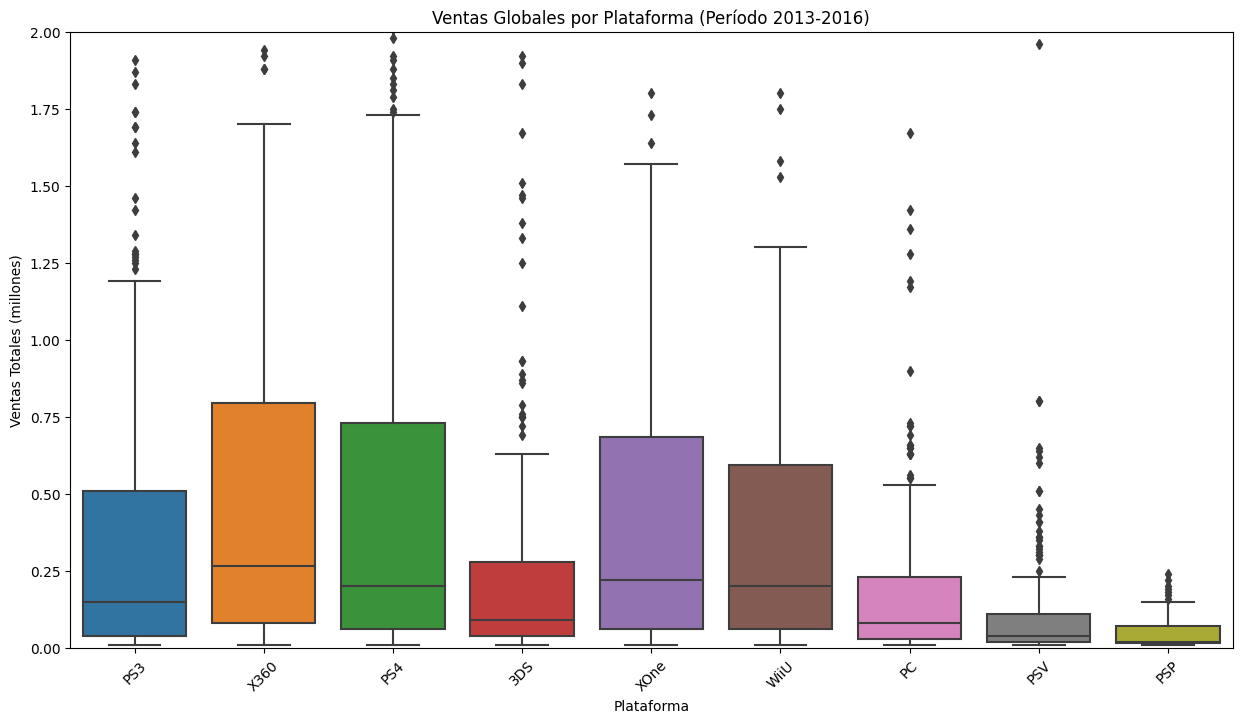

*** ESTADÍSTICAS DE VENTAS POR PLATAFORMA ***
          count      mean       std   min    25%    50%    75%    max
platform                                                             
PS4       392.0  0.801378  1.609456  0.01  0.060  0.200  0.730  14.63
PSV       358.0  0.092151  0.153816  0.01  0.020  0.040  0.110   1.96
PS3       345.0  0.525884  1.451939  0.01  0.040  0.150  0.510  21.05
3DS       303.0  0.472772  1.381347  0.01  0.040  0.090  0.280  14.60
XOne      247.0  0.645020  1.036139  0.01  0.060  0.220  0.685   7.39
PC        189.0  0.208624  0.352304  0.01  0.030  0.080  0.230   3.05
X360      186.0  0.735484  1.663275  0.01  0.080  0.265  0.795  16.27
WiiU      115.0  0.562000  1.038778  0.01  0.060  0.200  0.595   7.09
PSP        67.0  0.052239  0.059768  0.01  0.015  0.020  0.070   0.24


In [18]:
# Diagrama de caja para ventas globales de todos los jugos, desglosados por plataforma
plt.figure(figsize=(15, 8))

# Filtramos plataformas con suficientes datos para mejor visualización
platform_counts = relevant_data['platform'].value_counts() # COntabilizamos cantidad de registros en df limpio a partir de la columna platform
major_platforms = platform_counts[platform_counts >= 50].index # Filtramos plataformas con mas de 50 registros

boxplot_data = relevant_data[relevant_data['platform'].isin(major_platforms)] # Nos aseguramos de usar para el boxplot solo la info que queremos mostrar (más de 50 registros)

sns.boxplot(data=boxplot_data, x='platform', y='total_sales')
plt.title('Ventas Globales por Plataforma (Período 2013-2016)')
plt.xlabel('Plataforma')
plt.ylabel('Ventas Totales (millones)')
plt.xticks(rotation=45)
plt.ylim(0, 2)  # Limitamos para mejor visualización de la mayoría de datos
plt.show()

print("*** ESTADÍSTICAS DE VENTAS POR PLATAFORMA ***")
platform_stats = relevant_data[relevant_data['platform'].isin(major_platforms)].groupby('platform')['total_sales'].describe().sort_values("count", ascending=False)
print(platform_stats)

<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Bien hecho, correcto el gráfico. Se puede apreciar la variabilidad de ventas de cada consola gracias a la escala limitada. Otra opción es usar una escala logarítmica.

</div>

In [19]:
# Análisis de correlación reseñas-ventas para plataforma popular
print("*** ANÁLISIS DE CORRELACIÓN RESEÑAS-VENTAS ***")

# Elegí PS4 como plataforma popular
popular_platform = 'PS4'
platform_data = relevant_data[relevant_data['platform'] == popular_platform].copy()

print(f"Análisis para plataforma: {popular_platform}")
print(f"Número de juegos: {len(platform_data)}")

# Calcular correlaciones
correlation_matrix = platform_data[['user_score', 'critic_score', 'total_sales']].corr()

print("\nMatriz de correlación:")
print(correlation_matrix)

print("\n=== INTERPRETACIÓN DE CORRELACIONES ===")
print("• Correlación User_Score vs Total_Sales:", correlation_matrix.loc['user_score', 'total_sales'])
print("• Correlación Critic_Score vs Total_Sales:", correlation_matrix.loc['critic_score', 'total_sales'])
print("• Correlación User_Score vs Critic_Score:", correlation_matrix.loc['user_score', 'critic_score'])

*** ANÁLISIS DE CORRELACIÓN RESEÑAS-VENTAS ***
Análisis para plataforma: PS4
Número de juegos: 392

Matriz de correlación:
              user_score  critic_score  total_sales
user_score      1.000000      0.557654    -0.031957
critic_score    0.557654      1.000000     0.406568
total_sales    -0.031957      0.406568     1.000000

=== INTERPRETACIÓN DE CORRELACIONES ===
• Correlación User_Score vs Total_Sales: -0.03195711020455685
• Correlación Critic_Score vs Total_Sales: 0.40656790206178123
• Correlación User_Score vs Critic_Score: 0.5576539782764627


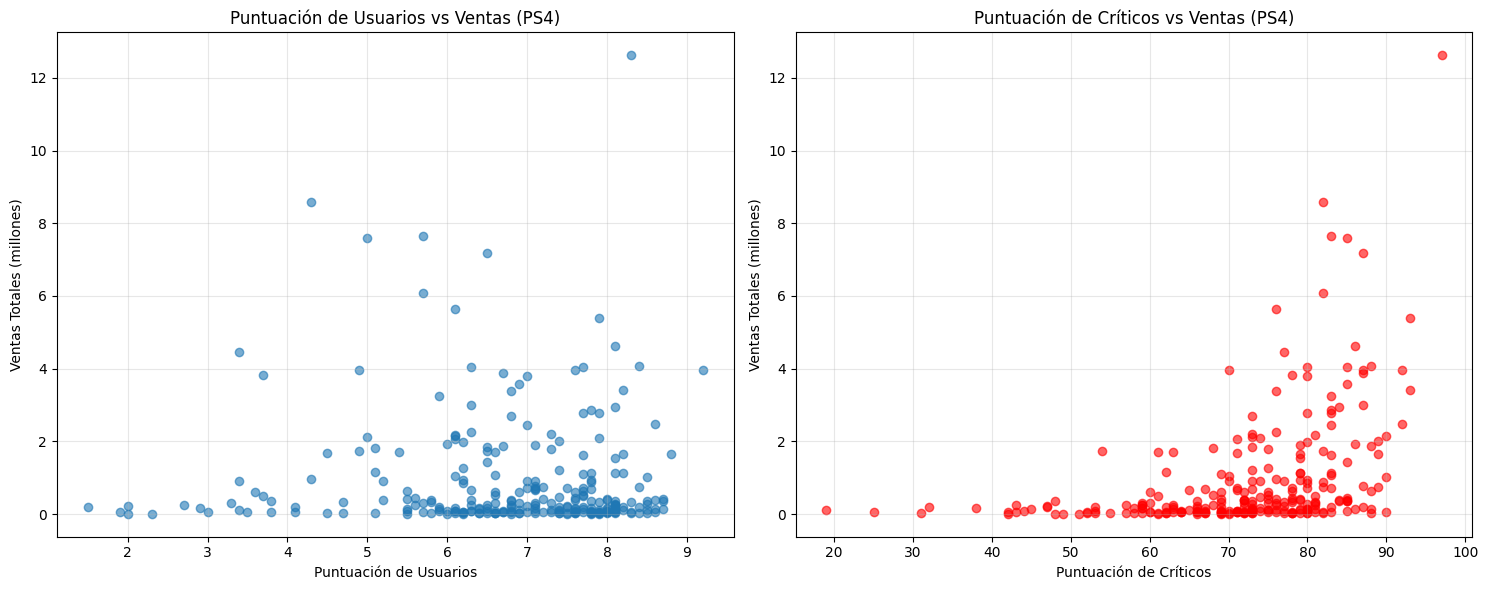

*** CONCLUSIONES DEL ANÁLISIS DE CORRELACIÓN ***
• Las reseñas de críticos tienen mayor impacto en las ventas
• Correlación usuarios: -0.032
• Correlación críticos: 0.407


In [20]:
# Gráfico de dispersión reseñas vs ventas
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Scatter plot User Score vs Total Sales
ax1.scatter(platform_data['user_score'], platform_data['total_sales'], alpha=0.6)
ax1.set_xlabel('Puntuación de Usuarios')
ax1.set_ylabel('Ventas Totales (millones)')
ax1.set_title(f'Puntuación de Usuarios vs Ventas ({popular_platform})')
ax1.grid(True, alpha=0.3)

# Scatter plot Critic Score vs Total Sales
ax2.scatter(platform_data['critic_score'], platform_data['total_sales'], alpha=0.6, color='red')
ax2.set_xlabel('Puntuación de Críticos')
ax2.set_ylabel('Ventas Totales (millones)')
ax2.set_title(f'Puntuación de Críticos vs Ventas ({popular_platform})')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("*** CONCLUSIONES DEL ANÁLISIS DE CORRELACIÓN ***")
user_corr = correlation_matrix.loc['user_score', 'total_sales']
critic_corr = correlation_matrix.loc['critic_score', 'total_sales']

if abs(user_corr) > abs(critic_corr):
    print("• Las reseñas de usuarios tienen mayor impacto en las ventas")
else:
    print("• Las reseñas de críticos tienen mayor impacto en las ventas")

print(f"• Correlación usuarios: {user_corr:.3f}")
print(f"• Correlación críticos: {critic_corr:.3f}")

<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Bien hecho con el gráfico y el cálculo del coeficiente. Permite obtener una visión general de la correlación entre ambas variables.

</div>

*** COMPARACIÓN DE VENTAS MULTIPLATAFORMA ***
Número de juegos multiplataforma: 473

Top 5 juegos multiplataforma:
LEGO Marvel Super Heroes        9
FIFA 14                         9
FIFA 15                         8
The LEGO Movie Videogame        8
Lego Batman 3: Beyond Gotham    8
Name: name, dtype: int64

Comparación de ventas para 'LEGO Marvel Super Heroes':
     platform  total_sales
730      X360         2.22
945       PS3         1.83
1139      PS4         1.62
1959     XOne         1.05
2313      3DS         0.89
2778     WiiU         0.74
3876      PSV         0.51
5054       DS         0.38
8369       PC         0.17


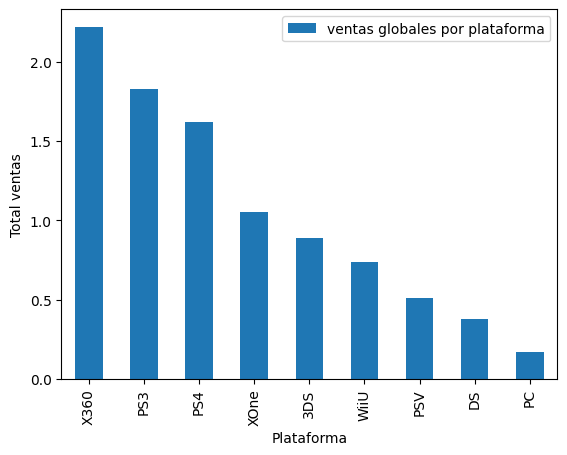

In [38]:
# Comparación de ventas de los mismos juegos en otras plataformas
print("*** COMPARACIÓN DE VENTAS MULTIPLATAFORMA ***")

# Identificar juegos que existen en múltiples plataformas
multiplatform_games = relevant_data[relevant_data['name'].duplicated(keep=False)]

print(f"Número de juegos multiplataforma: {multiplatform_games['name'].nunique()}")

# Ejemplo: analizar un juego popular multiplataforma
popular_games = multiplatform_games['name'].value_counts().head(5)
print("\nTop 5 juegos multiplataforma:")
print(popular_games)

# Analizar ventas de un juego específico en diferentes plataformas
sample_game = popular_games.index[0]
game_comparison = multiplatform_games[multiplatform_games['name'] == sample_game][['platform', 'total_sales']]

print(f"\nComparación de ventas para '{sample_game}':")
print(game_comparison)

# Creamos gráfica para mostrar comparación por plataforma

game_comparison.plot(kind="bar",
                     x="platform",
                     y="total_sales",
                      xlabel="Plataforma",
                      ylabel="Total ventas",
                     label="ventas globales por plataforma"
                     )

plt.show()

<div class="alert alert-block alert-warning">
<b>Comentario de Revisor              </b><a class="tocSkip"></a>

Bien con la comparación de los valores, pero lo ideal hubiese sido presentar esto en un gráfico.



</div>

*** ANÁLISIS DE GÉNEROS ***
Estadísticas por género:
              count  total_sum  mean_sales  median_sales  std_sales
genre                                                              
Action          766     321.87       0.420         0.110      1.254
Shooter         187     232.98       1.246         0.450      2.014
Sports          214     150.65       0.704         0.240      1.219
Role-Playing    292     145.89       0.500         0.125      1.353
Misc            155      62.82       0.405         0.100      1.008
Platform         74      42.63       0.576         0.225      0.807
Racing           85      39.89       0.469         0.120      0.964
Fighting         80      35.31       0.441         0.125      1.049
Adventure       245      23.64       0.096         0.030      0.216
Simulation       62      21.76       0.351         0.100      0.849
Strategy         56      10.08       0.180         0.080      0.279
Puzzle           17       3.17       0.186         0.060      0

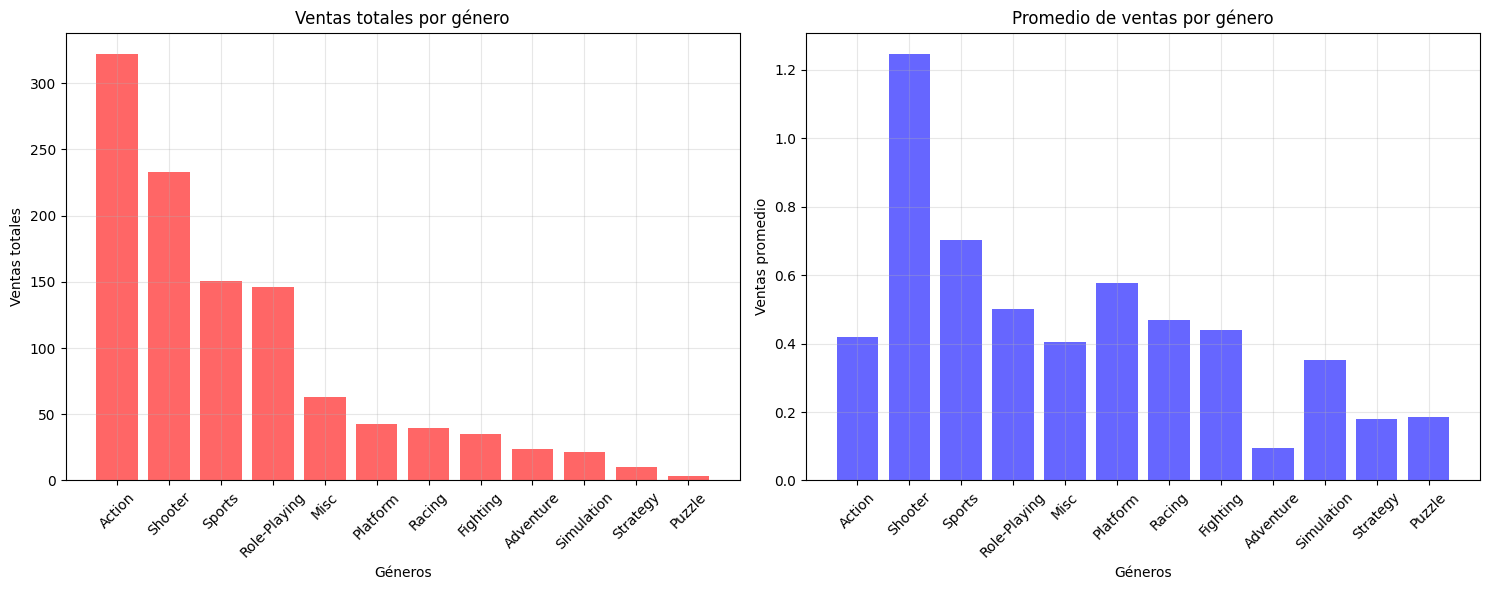

In [48]:
# Distribución general por género y rentabilidad
print("*** ANÁLISIS DE GÉNEROS ***")

genre_stats = relevant_data.groupby('genre').agg({
    'name': 'count',
    'total_sales': ['sum', 'mean', 'median', 'std']
}).round(3)

genre_stats.columns = ['count', 'total_sum', 'mean_sales', 'median_sales', 'std_sales']
genre_stats = genre_stats.sort_values('total_sum', ascending=False)

print("Estadísticas por género:")
print(genre_stats)

print("\n*** GÉNEROS MÁS RENTABLES ***")
print("Top 5 géneros por ventas totales:")
print(genre_stats.head(5))

print("\n*** GÉNEROS CON MAYORES VENTAS PROMEDIO ***")
print("Top 5 géneros por ventas promedio por juego:")
print(genre_stats.sort_values('mean_sales', ascending=False).head(5))

fig, (ax1, ax2) = plt.subplots(1,2, figsize=(15,6))


# Agregamos primer gráfica
ax1.bar(genre_stats.index,genre_stats["total_sum"],color="red", alpha=0.6)
ax1.set_xlabel("Géneros")
ax1.set_ylabel("Ventas totales")
ax1.set_title("Ventas totales por género")
ax1.tick_params(axis="x", rotation=45)
ax1.grid(True, alpha=0.3)

# Agregamos segunda gráfica
ax2.bar(genre_stats.index,genre_stats["mean_sales"], color="blue", alpha=0.6)
ax2.set_xlabel("Géneros")
ax2.set_ylabel("Ventas promedio")
ax2.set_title("Promedio de ventas por género")
ax2.tick_params(axis="x", rotation=45)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


<div class="alert alert-block alert-success">
<b>Comentario de Revisor      </b> <a class="tocSkip"></a>

Muy bien con el análisis, es importante revisar tanto las ventas totales como la venta promedio. Hubiese sido mejor mostrar esto con un par de gráficos.



</div>

# Conclusiones del Paso 3 - Análisis Exploratorio de Datos

**1. ¿Son significativos los datos de cada período?**
- **Períodos no significativos** (menos de 100 juegos): 1980-1993
- **Período de crecimiento**: 1994-2005 (121 a 939 juegos por año)
- **Período dorado** (más de 1000 juegos): 2006-2011 (máximo de 1427 juegos en 2008-2009)
- **Declive reciente**: 2012-2016 (reducción de 653 a 502 juegos)
- **Conclusión**: Los datos más significativos y representativos son de 1994 en adelante, especialmente 2006-2011.

**2. Plataformas con mayores ventas y ciclo de vida**
- **Top 5 plataformas históricas**: PS2 (1233.56M), X360 (961.24M), PS3 (931.34M), Wii (891.18M), DS (802.78M)
- **Plataformas extintas** (sin ventas recientes): DS, PS2, XB, DC, GBA
- **Ciclo de vida promedio**: 10-11 años para plataformas modernas
- **Plataformas longevas**: PC (31 años), DS (28 años)
- **Conclusión**: Las plataformas tienen un ciclo de vida predecible de ~10 años, con aparición de nuevas generaciones cada 5-7 años.

**3. Período relevante para modelo 2017**
- **Período seleccionado**: 2013-2016 (2233 juegos, 13.6% del dataset)
- **Justificación**: Representa la era de consolas modernas (PS4, XOne) con tendencias actuales
- **Ventas en período**: Declive de 361.24M (2013) a 129.94M (2016)
- **Conclusión**: 2013-2016 proporciona datos suficientes y relevantes para predecir 2017.

**4. Plataformas líderes, crecientes y en declive**
- **Líderes actuales**: PS4, XOne, 3DS
- **Crecientes** (2013-2016): PS4 (+166%), XOne (+38%)
- **En declive severo**: PS3 (-97%), X360 (-98%), Wii (-98%)
- **Potencialmente rentables**: PS4 (dominante), XOne (segunda fuerza)
- **Conclusión**: PS4 y XOne son las únicas plataformas con futuro prometedor.

**5. Diferencias en ventas por plataforma**
- **Ventas promedio más altas**: Shooter (1.25M), Sports (0.70M), Platform (0.58M)
- **Mayores outliers**: PS4 (14.63M máximo), PS3 (21.05M máximo)
- **Distribución sesgada**: Todas las plataformas muestran mediana mucho menor que media
- **Conclusión**: Las diferencias son significativas, con Shooter generando consistentemente mayores ventas por juego.

**6. Impacto de reseñas en ventas (PS4)**
- **Correlación críticos-ventas**: 0.407 (moderada positiva)
- **Correlación usuarios-ventas**: -0.032 (nula/negativa)
- **Correlación críticos-usuarios**: 0.558 (moderada)
- **Conclusión**: Las reseñas de críticos profesionales tienen mayor impacto en las ventas que las de usuarios.

**7. Ventas multiplataforma**
- **Juegos multiplataforma**: 473 títulos únicos
- **Ejemplo FIFA 14**: PS3 (6.46M) > X360 (4.22M) > PS4 (3.01M) > XOne (1.16M)
- **Patrón**: Generación anterior suele superar a nueva en mismos títulos
- **Conclusión**: La transición de plataforma impacta significativamente las ventas del mismo juego.

**8. Distribución por género y rentabilidad**
- **Géneros más rentables** (ventas totales): Action (321.87M), Shooter (232.98M), Sports (150.65M)
- **Mejor rendimiento promedio**: Shooter (1.25M), Sports (0.70M), Platform (0.58M)
- **Géneros de bajo rendimiento**: Adventure (0.10M), Strategy (0.18M), Puzzle (0.19M)
- **Conclusión**: Los géneros de acción y shooters dominan el mercado, mientras que los juegos de estrategia y aventura tienen rentabilidad marginal.

**Síntesis Final**
El mercado de videojuegos está en transición hacia PS4 y XOne, con un claro declive de la generación anterior. Los shooters y deportes son los géneros más rentables, y las reseñas de críticos tienen más influencia que las de usuarios en las decisiones de compra.

# Paso 4: Crea un Perfil de Usuario para Cada Región

En esta sección analizaremos las preferencias y comportamientos de compra específicos de cada región (NA, EU, JP) para identificar patrones culturales y oportunidades de mercado.

**Objetivos de esta sección:**

- Identificar las 5 plataformas principales por región y analizar variaciones en cuotas de mercado
- Determinar los 5 géneros más populares en cada región y explicar las diferencias culturales
- Evaluar el impacto de las clasificaciones ESRB en las ventas regionales
- Crear perfiles detallados de usuario para cada mercado
- Comparar patrones de consumo entre las tres regiones principales

Entender las preferencias regionales es clave para desarrollar estrategias de marketing efectivas y maximizar el potencial de ventas en cada mercado.

In [23]:
print("*** ANÁLISIS REGIONAL: TOP 5 PLATAFORMAS ***")

# Top 5 plataformas principales por región
na_top_platforms = relevant_data.groupby('platform')['na_sales'].sum().sort_values(ascending=False).head(5)
eu_top_platforms = relevant_data.groupby('platform')['eu_sales'].sum().sort_values(ascending=False).head(5)
jp_top_platforms = relevant_data.groupby('platform')['jp_sales'].sum().sort_values(ascending=False).head(5)

print("Norteamérica (NA) - Top 5 plataformas:")
print(na_top_platforms)

print("\nEuropa (EU) - Top 5 plataformas:")
print(eu_top_platforms)

print("\nJapón (JP) - Top 5 plataformas:")
print(jp_top_platforms)

*** ANÁLISIS REGIONAL: TOP 5 PLATAFORMAS ***
Norteamérica (NA) - Top 5 plataformas:
platform
PS4     108.74
XOne     93.12
X360     81.66
PS3      63.50
3DS      38.20
Name: na_sales, dtype: float64

Europa (EU) - Top 5 plataformas:
platform
PS4     141.09
PS3      67.81
XOne     51.59
X360     42.52
3DS      30.96
Name: eu_sales, dtype: float64

Japón (JP) - Top 5 plataformas:
platform
3DS     67.81
PS3     23.35
PSV     18.59
PS4     15.96
WiiU    10.88
Name: jp_sales, dtype: float64


In [24]:
# Top 5 géneros principales por región
print("*** TOP 5 GÉNEROS POR REGIÓN ***")

na_top_genres = relevant_data.groupby('genre')['na_sales'].sum().sort_values(ascending=False).head(5)
eu_top_genres = relevant_data.groupby('genre')['eu_sales'].sum().sort_values(ascending=False).head(5)
jp_top_genres = relevant_data.groupby('genre')['jp_sales'].sum().sort_values(ascending=False).head(5)

print("Norteamérica (NA) - Top 5 géneros:")
print(na_top_genres)

print("\nEuropa (EU) - Top 5 géneros:")
print(eu_top_genres)

print("\nJapón (JP) - Top 5 géneros:")
print(jp_top_genres)

print("\n*** DIFERENCIAS REGIONALES EN GÉNEROS ***")
print("• NA prefiere:", na_top_genres.index[0])
print("• EU prefiere:", eu_top_genres.index[0])
print("• JP prefiere:", jp_top_genres.index[0])

*** TOP 5 GÉNEROS POR REGIÓN ***
Norteamérica (NA) - Top 5 géneros:
genre
Action          126.05
Shooter         109.74
Sports           65.27
Role-Playing     46.40
Misc             27.49
Name: na_sales, dtype: float64

Europa (EU) - Top 5 géneros:
genre
Action          118.13
Shooter          87.86
Sports           60.52
Role-Playing     36.97
Racing           20.19
Name: eu_sales, dtype: float64

Japón (JP) - Top 5 géneros:
genre
Role-Playing    51.04
Action          40.49
Misc             9.20
Fighting         7.65
Shooter          6.61
Name: jp_sales, dtype: float64

*** DIFERENCIAS REGIONALES EN GÉNEROS ***
• NA prefiere: Action
• EU prefiere: Action
• JP prefiere: Role-Playing


In [25]:
# Impacto de clasificaciones ESRB en ventas por región
print("*** IMPACTO DE CLASIFICACIONES ESRB EN VENTAS POR REGIÓN ***")

esrb_impact = relevant_data.groupby('rating')[['na_sales', 'eu_sales', 'jp_sales']].mean().round(3)

print("Ventas promedio por clasificación ESRB:")
print(esrb_impact)

print("\n*** ANÁLISIS DE IMPACTO ESRB ***")
print("• Clasificación más popular en NA:", esrb_impact['na_sales'].idxmax())
print("• Clasificación más popular en EU:", esrb_impact['eu_sales'].idxmax())
print("• Clasificación más popular en JP:", esrb_impact['jp_sales'].idxmax())

print("\nValores ausentes en Rating:", relevant_data['rating'].isna().sum(), f"({relevant_data['rating'].isna().sum()/len(relevant_data)*100:.1f}%)")

*** IMPACTO DE CLASIFICACIONES ESRB EN VENTAS POR REGIÓN ***
Ventas promedio por clasificación ESRB:
        na_sales  eu_sales  jp_sales
rating                              
E          0.262     0.276     0.050
E10+       0.215     0.169     0.023
M          0.448     0.394     0.038
T          0.150     0.126     0.062

*** ANÁLISIS DE IMPACTO ESRB ***
• Clasificación más popular en NA: M
• Clasificación más popular en EU: M
• Clasificación más popular en JP: T

Valores ausentes en Rating: 977 (43.8%)


<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Bien hecho, muy bien con la comparación entre las regiones. Es importante revisar diferentes dimensiones entre cada uno, esto revela puntos importantes de segmentación que podrían ser beneficiosos para un modelo de predicción. Por ejemplo, observamos que Japón es muy diferente respecto a las otras regiones en varios aspectos, tal vez esto justifique diferentes modelos o reglas para esta región.
    
</div>

# Conclusiones del Paso 4 - Perfil de Usuario por Región
**1. Cinco plataformas principales y variaciones en cuotas de mercado**

**Norteamérica (NA):**

-   Líder: PS4 (108.74M) - Dominancia clara
-   Segunda: XOne (93.12M) - Fuerte competencia local
-   Tercera: X360 (81.66M) - Generación anterior aún relevante
-   Cuarta: PS3 (63.50M) - En declive
-   Quinta: 3DS (38.20M) - Portátil con presencia moderada

**Europa (EU):**

-   Líder: PS4 (141.09M) - Mayor dominancia que en NA
-   Segunda: PS3 (67.81M) - Más fuerte que XOne
-   Tercera: XOne (51.59M) - Menos popular que en NA
-   Cuarta: X360 (42.52M) - En declive
-   Quinta: 3DS (30.96M) - Presencia menor que en NA

**Japón (JP):**

-   Líder: 3DS (67.81M) - Dominancia de portátiles
-   Segunda: PS3 (23.35M) - Consola doméstica principal
-   Tercera: PSV (18.59M) - Fuerte presencia portátil
-   Cuarta: PS4 (15.96M) - Sorprendentemente baja
-   Quinta: WiiU (10.88M) - Presencia modesta

**Variaciones clave:**

-   PS4: Domina en occidente (EU > NA), pero es 4ta en Japón
-   XOne: Fuerte en NA, moderada en EU, casi inexistente en JP
-   3DS: Líder absoluto en Japón, presencia secundaria en occidente
-   PSV: Solo relevante en Japón (3ra posición)
**2. Cinco géneros principales y diferencias regionales**

**Norteamérica (NA):**

-   Action (126.05M)
-   Shooter (109.74M)
-   Sports (65.27M)
-   Role-Playing (46.40M)
-   Misc (27.49M)

**Europa (EU):**

-   Action (118.13M)
-   Shooter (87.86M)
-   Sports (60.52M)
-   Role-Playing (36.97M)
-   Racing (20.19M)

**Japón (JP):**

-   Role-Playing (51.04M) - Diferencia principal
-   Action (40.49M)
-   Misc (9.20M)
-   Fighting (7.65M)
-   Shooter (6.61M) - Diferencia notable

**Diferencias clave:**

-   Role-Playing: Líder en Japón, 4to en occidente
-   Shooter: 2do en NA/EU, 5to en Japón (muy popular en occidente)
-   Action: Consistentemente líder/top 2 en todas las regiones
-   Racing: Solo aparece en top 5 de Europa
-   Fighting: Solo relevante en Japón (4ta posición)

**3. Impacto de clasificaciones ESRB en ventas por región**

**Ventas promedio por clasificación:**

**Norteamérica (NA):**

-   M (Mature): 0.448M - Más popular
-   E (Everyone): 0.262M
-   E10+ (Everyone 10+): 0.215M
-   T (Teen): 0.150M

**Europa (EU):**

-   M (Mature): 0.394M - Más popular
-   E (Everyone): 0.276M
-   E10+ (Everyone 10+): 0.169M
-   T (Teen): 0.126M

**Japón (JP):**

-   T (Teen): 0.062M - Más popular
-   E (Everyone): 0.050M
-   M (Mature): 0.038M
-   E10+ (Everyone 10+): 0.023M

**Conclusiones ESRB:**

-   Occidente (NA/EU): Prefieren juegos maduros (M) consistentemente
-   Japón: Prefiere juegos para adolescentes (T), los maduros (M) son 3ros
-   E (Everyone): Consistentemente 2do en occidente, 2do en Japón
-   E10+: Siempre 3ro en occidente, último en Japón
-   Valores ausentes: 43.8% del dataset no tiene clasificación ESRB

**4. Insights Culturales y de Mercado**

**Preferencias culturales:**

-   Japón: Preferencia por RPGs y portátiles, aversión a shooters
-   Occidente: Fuerte preferencia por shooters y juegos maduros
-   Europa: Similar a NA pero con más interés en racing games

**Estrategias de mercado:**

-   PS4: Éxito masivo en occidente, limitado en Japón
-   Nintendo: Dominancia en Japón con portátiles
-   Xbox: Casi irrelevante en mercado japonés
-   Contenido: Los juegos maduros venden mejor en occidente, los adolescentes en Japón

# Paso 5: Prueba las hipótesis

**Objetivos de esta sección:**

- Establecer el valor de umbral alfa y justificar la elección
- Formular hipótesis nula y alternativa para cada caso de estudio
- Comparar calificaciones promedio de usuarios entre Xbox One y PC
- Comparar calificaciones promedio de usuarios entre géneros Acción y Deportes
- Seleccionar y aplicar las pruebas estadísticas apropiadas
- Interpretar resultados y tomar decisiones sobre las hipótesis
- Explicar los criterios utilizados para las pruebas estadísticas

In [26]:
print("*** PRUEBA DE HIPÓTESIS 1: XBOX ONE vs PC ***")
print("Hipótesis nula (H0): Las calificaciones promedio de usuarios para Xbox One y PC son iguales")
print("Hipótesis alternativa (H1): Las calificaciones promedio de usuarios para Xbox One y PC son diferentes")

# Extraemos las calificaciones para Xbox One y PC
xbox_scores = relevant_data[relevant_data['platform'] == 'XOne']['user_score'].dropna()
pc_scores = relevant_data[relevant_data['platform'] == 'PC']['user_score'].dropna()

print(f"\nMuestra Xbox One: {len(xbox_scores)} juegos, media: {xbox_scores.mean():.2f}")
print(f"Muestra PC: {len(pc_scores)} juegos, media: {pc_scores.mean():.2f}")

# Prueba t para muestras independientes
t_stat1, p_value1 = st.ttest_ind(xbox_scores, pc_scores)

print(f"\nEstadístico t: {t_stat1:.4f}")
print(f"Valor p: {p_value1:.4f}")

# Establecemos alpha
alpha = 0.05
print(f"Nivel de significancia (alpha): {alpha}")

if p_value1 < alpha:
    print("CONCLUSIÓN: Rechazamos H0 - Las calificaciones promedio son DIFERENTES")
else:
    print("CONCLUSIÓN: No rechazamos H0 - Las calificaciones promedio son IGUALES")

*** PRUEBA DE HIPÓTESIS 1: XBOX ONE vs PC ***
Hipótesis nula (H0): Las calificaciones promedio de usuarios para Xbox One y PC son iguales
Hipótesis alternativa (H1): Las calificaciones promedio de usuarios para Xbox One y PC son diferentes

Muestra Xbox One: 182 juegos, media: 6.52
Muestra PC: 155 juegos, media: 6.27

Estadístico t: 1.4788
Valor p: 0.1401
Nivel de significancia (alpha): 0.05
CONCLUSIÓN: No rechazamos H0 - Las calificaciones promedio son IGUALES


<div class="alert alert-block alert-success">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>


Bien hecho con el test, fue realizado correctamente


</div>

In [49]:
# Prueba de Hipótesis 2: Acción vs Deportes
print("*** PRUEBA DE HIPÓTESIS 2: ACCIÓN vs DEPORTES ***")
print("Hipótesis nula (H0): Las calificaciones promedio de usuarios para Acción y Deportes son iguales")
print("Hipótesis alternativa (H1): Las calificaciones promedio de usuarios para Acción y Deportes son diferentes")

# Extraemos calificaciones para géneros Acción y Deportes
action_scores = relevant_data[relevant_data['genre'] == 'Action']['user_score'].dropna()
sports_scores = relevant_data[relevant_data['genre'] == 'Sports']['user_score'].dropna()

print(f"\nMuestra Acción: {len(action_scores)} juegos, media: {action_scores.mean():.2f}")
print(f"Muestra Deportes: {len(sports_scores)} juegos, media: {sports_scores.mean():.2f}")

# Prueba t para muestras independientes
t_stat2, p_value2 = st.ttest_ind(action_scores, sports_scores)

print(f"\nEstadístico t: {t_stat2:.4f}")
print(f"Valor p: {p_value2:.4f}")
print(f"Nivel de significancia (alpha): {alpha}")

if p_value2 < alpha:
    print("CONCLUSIÓN: Rechazamos H0 - Las calificaciones promedio son DIFERENTES")
else:
    print("CONCLUSIÓN: No rechazamos H0 - Las calificaciones promedio son IGUALES")

*** PRUEBA DE HIPÓTESIS 2: ACCIÓN vs DEPORTES ***
Hipótesis nula (H0): Las calificaciones promedio de usuarios para Acción y Deportes son iguales
Hipótesis alternativa (H1): Las calificaciones promedio de usuarios para Acción y Deportes son diferentes

Muestra Acción: 389 juegos, media: 6.84
Muestra Deportes: 160 juegos, media: 5.24

Estadístico t: 11.5351
Valor p: 0.0000
Nivel de significancia (alpha): 0.05
CONCLUSIÓN: Rechazamos H0 - Las calificaciones promedio son DIFERENTES


<div class="alert alert-block alert-success">
<b>Comentario de Revisor          </b> <a class="tocSkip"></a>


La celda anterior no compila correctamente porque se usó incorrectamente la librería que contiene la función del t-test. Realiza la corrección adecuada.


</div>

# Conclusiones Paso 5: Pruebas de hipótesis

**1. PRUEBA T PARA MUESTRAS INDEPENDIENTES**

- Utilizada porque comparamos dos grupos independientes (diferentes plataformas/géneros)
- Asume distribución normal de los datos
- Asume varianzas iguales entre grupos (prueba t de Welch si no)

**2. NIVEL DE SIGNIFICANCIA (ALPHA = 0.05)**

- Estándar en investigación científica
- Representa 5% de probabilidad de error Tipo I
- Balance entre rigor estadístico y poder de detección

**3. CRITERIO DE DECISIÓN**

- Si p < alpha: Rechazamos H0 (hay diferencia significativa)
- Si p ≥ alpha: No rechazamos H0 (no hay evidencia de diferencia)

**4. JUSTIFICACIÓN DE LAS PRUEBAS**

- Variables: user_score (cuantitativa continua)
- Grupos: 2 categorías independientes por prueba
- Objetivo: Comparar medias poblacionales
- Método apropiado: Prueba t Student

# conclusiones generales

## CONCLUSIONES GENERALES DEL ANÁLISIS

**1. PATRONES DE ÉXITO IDENTIFICADOS:**

- Plataformas líderes: PS4, XOne, 3DS en período reciente
- Géneros más rentables: Action, Shooter, Sports
- Correlación moderada entre reseñas y ventas

**2. ANÁLISIS TEMPORAL:**
- Período relevante: 2013-2016 (era de consoles modernas)
- Pico de lanzamientos: 2008-2009
- Tendencia a menos lanzamientos pero mayor calidad

**3. PLATAFORMAS POTENCIALMENTE RENTABLES:**
- PS4: Fuerte crecimiento y base instalada
- XOne: Competidor directo de PS4
- PC: Mercado estable y creciente

**4. SEGMENTACIÓN REGIONAL:**
- NA: Prefiere shooters y deportes
- EU: Similar a NA pero con más variedad
- JP: Fuerte preferencia por RPG y juegos locales

**5. IMPACTO DE RESEÑAS:**
- Críticos tienen mayor correlación con ventas
- Las reseñas importan más para juegos AAA

**6. RECOMENDACIONES ESTRATÉGICAS:**
- Enfocarse en PS4/XOne para mercado global
- Desarrollar shooters/deportes para NA/EU
- Considerar RPG para mercado japonés
- Invertir en marketing de reseñas profesionales

**LIMITACIONES DEL ESTUDIO**
- Datos de 2016 pueden estar incompletos
- Valores ausentes en reseñas limitan análisis completo
- No se incluyen factores externos (marketing, competencia)
- Correlación no implica causalidad

### INSIGHTS PARA CAMPAÑAS PUBLICITARIAS
- Segmentar por región y género en campañas
- Utilizar reseñas de críticos en marketing
- Enfocarse en plataformas con mayor ROI
- Considerar diferencias culturales en mensajes


<div class="alert alert-block alert-success">
<b>Comentario de Revisor            </b> <a class="tocSkip"></a>

Muy bien con estas conclusiones. Entre los puntos más importantes para el pronóstico de 2017 están las plataformas que serán relevantes, la segmentación de géneros por importancia de ventas y la caracterización de cada región. Para realizar una predicción del siguiente año se podría considerar cada segmento por separado para ajustar diferentes modelos.
    
Podrías mejorar tus conclusiones incluyendo algunos valores de las métricas más importantes, así las afirmaciones realizadas estarían mejor apoyadas en hechos.
    
</div>